# **Fatores do Baixo Peso ao Nascer no Rio Grande do Norte**
## Análise Econométrica com Dados do SINASC

O **baixo peso ao nascer (BPN)**, definido pela OMS como peso inferior a **2.500 gramas**, é um indicador de saúde pública de extrema importância por estar associado a morbidades, mortalidade neonatal e repercussões socioeconômicas ao longo da vida. No Brasil, estima-se que cerca de 8% dos nascidos apresentam BPN.

Este notebook reproduz e expande a análise econométrica realizada por mim no trabalho final da disciplina de Econometria no Mestrado de Economia Aplicada, entitulado *"Fatores do Baixo Peso ao Nascer no Rio Grande do Norte: Análise Econométrica com Dados do SINASC"*, que utiliza dados públicos das **Declarações de Nascidos Vivos de 2023** do estado do Rio Grande do Norte, disponíveis no [SINASC/DATASUS](https://datasus.saude.gov.br/).

O objetivo é identificar os fatores socioeconômicos e clínicos associados ao BPN e quantificar seus impactos, fornecendo uma análise quantitativa útil para profissionais de saúde e gestores públicos na formulação de políticas voltadas à redução do BPN.

---

**Fonte dos dados:** SINASC — Sistema de Informações sobre Nascidos Vivos. Ministério da Saúde / DATASUS. Declarações de Nascidos Vivos, Rio Grande do Norte, 2023.  

## **Preparação do Notebook**

In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys, os

sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2

import statsmodels.api as sm

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import shap

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 150,
    }
)

vermelho = "#c0392b"
cinza = "#2c3e50"

seed = 42

## **Leitura dos Dados**

Os dados utilizados provêm do **SINASC (Sistema de Informações sobre Nascidos Vivos)**, disponibilizados pelo Ministério da Saúde via [DATASUS](https://datasus.saude.gov.br/). A base cobre as **Declarações de Nascidos Vivos de 2023** para o estado do **Rio Grande do Norte**, com informações sobre gestação, parto, condições do recém-nascido e características socioeconômicas da mãe. As variáveis escolhidas estão de acordo com a revisão de literatura feita no desenvolvimento do trabalho.

In [2]:
df = pd.read_csv("../data/declaracao_nascidos_vivos.csv", sep=",", low_memory=False)
df.head(5)

,ano,sigla_uf,sigla_uf_nome,sexo,peso,id_anomalia,semana_gestacao,tipo_gravidez,tipo_parto,pre_natal_agr,quantidade_filhos_vivos,quantidade_filhos_mortos,idade_mae,escolaridade_mae,estado_civil_mae,raca_cor_mae,gestacoes_ant
0,2023,RN,Rio Grande do Norte,Feminino,2290.0,Não,41.0,Única,Vaginal,7 e mais consultas,0.0,0.0,33,12 e mais,Solteira,Branca,0.0
1,2023,RN,Rio Grande do Norte,Masculino,2700.0,Não,35.0,Única,Vaginal,7 e mais consultas,0.0,0.0,21,8 a 11 anos,Solteira,Parda,0.0
2,2023,RN,Rio Grande do Norte,Feminino,2340.0,NaN,40.0,Única,Vaginal,7 e mais consultas,0.0,0.0,19,8 a 11 anos,União estável,Parda,0.0
3,2023,RN,Rio Grande do Norte,Masculino,1600.0,Não,30.0,Dupla,Vaginal,7 e mais consultas,0.0,0.0,15,4 a 7 anos,União estável,Parda,0.0
4,2023,RN,Rio Grande do Norte,Feminino,3850.0,Não,39.0,Única,Vaginal,7 e mais consultas,0.0,0.0,28,12 e mais,Solteira,Branca,0.0


## **Tratamento dos Dados**

Foram aplicados os critérios de exclusão utilizados por **Tolio et al. (2020)**:
- Registros com peso inferior a 500g
- Gestações com duração inferior a 22 semanas
- Combinações clinicamente inconsistentes de semana gestacional e peso
- Registros com dados declarados como **ignorados** em qualquer variável analítica
- Gestações múltiplas (gêmeos, trigêmeos etc.)

In [3]:
# remoção de colunas não utilizadas na análise
df = df.drop(columns=["ano", "sigla_uf_nome", "id_anomalia"])

# drop nulls
n_nulos = df.isna().sum().max()
df.dropna(inplace=True)

# gravidez múltipla
df = df[df.tipo_gravidez == "Única"]

# peso < 500g
df = df[df.peso >= 500]

# inconsistências clínicas conforme Tolio et al. (2020)
filtros_clinicos = (
    (df.semana_gestacao < 22)
    | ((df.semana_gestacao.between(22, 27)) & (df.peso > 1500))
    | ((df.semana_gestacao.between(28, 31)) & (df.peso > 2500))
    | ((df.semana_gestacao > 37) & (df.peso < 1500))
)
df = df[~filtros_clinicos]

# registros com dados declarados como ignorados
mask_ignorados = ((df == "Ignorado") | (df == "Ignorada") | (df == "Nenhuma")).sum(
    axis=1
) > 0
df = df[~mask_ignorados].reset_index(drop=True)
df.shape

(13276, 14)

Após os filtros, a amostra totalizou **13.276 registros**.

## **Variável Resposta e Feature Engineering**

A variável resposta `baixo_peso` é binária: 1 se o recém-nascido pesou menos de 2.500g (critério OMS), 0 caso contrário.

As covariáveis categóricas foram construídas com base na literatura:
- **Faixa etária da mãe**: `<20`, `20-24`, `25-29`, `30-34`, `35+` — captura o padrão em "U" descrito na literatura.
- **Filhos vivos**: `0`, `1-2`, `3+` — proxy de paridade.
- **Histórico de aborto**: binário derivado da quantidade de filhos mortos.
- **Estado conjugal**: agrupado em *com companheiro* e *sem companheiro*.
- **Cor**: dicotomizada em *Branca* vs *Não Branca*.

In [4]:
# variável resposta baixo peso ao nascer
df["baixo_peso"] = np.where(df.peso < 2500, 1, 0)

# faixa etária da mãe
df["faixa_idade_mae"] = pd.cut(
    df["idade_mae"],
    bins=[0, 19, 24, 29, 34, 60],
    labels=["<20", "20-24", "25-29", "30-34", "35+"],
    right=True,
)
# quantidade de filhos vivos
df["faixa_filhos_vivos"] = pd.cut(
    df["quantidade_filhos_vivos"],
    bins=[-1, 0, 2, 20],
    labels=["0", "1-2", "3+"],
    right=True,
)
# histórico de aborto
df["historico_aborto"] = np.where(df["quantidade_filhos_mortos"] > 0, "Sim", "Não")

# situação conjugal agrupada
df["estado_conjugal_grupo"] = np.where(
    df["estado_civil_mae"].isin(["Casada", "União estável"]),
    "Com companheiro",
    "Sem companheiro",
)
# cor da mãe
df["cor_mae_branca"] = np.where(df["raca_cor_mae"] == "Branca", "Branca", "Não Branca")

n_bpn = df.baixo_peso.sum()
taxa_bpn = df.baixo_peso.mean()
print(f"Nascidos com baixo peso: {n_bpn} ({taxa_bpn:.2%} da amostra)")

Nascidos com baixo peso: 1069 (8.05% da amostra)


## **Análise Exploratória**

Antes de modelar, exploramos a distribuição do peso ao nascer e as taxas de BPN por categoria de cada variável explicativa. Isso permite verificar quais fatores apresentam maior desequilíbrio na incidência do desfecho e orientar as expectativas para a modelagem.

In [5]:
# funções auxiliares para visualização
fontdict = {"size": 12}


def fmt_pct(value, _):
    return f"{value:.0f}%"


def add_caption(fig, caption):
    fig.text(
        x=0.035, y=-0.1, s=caption, ha="left", va="bottom", fontsize=10, color="black"
    )


def taxa_bpn_por_cat(series_col, target_series):
    """Taxa de BPN (%) por categoria."""
    return target_series.groupby(series_col, observed=True).mean().mul(100)

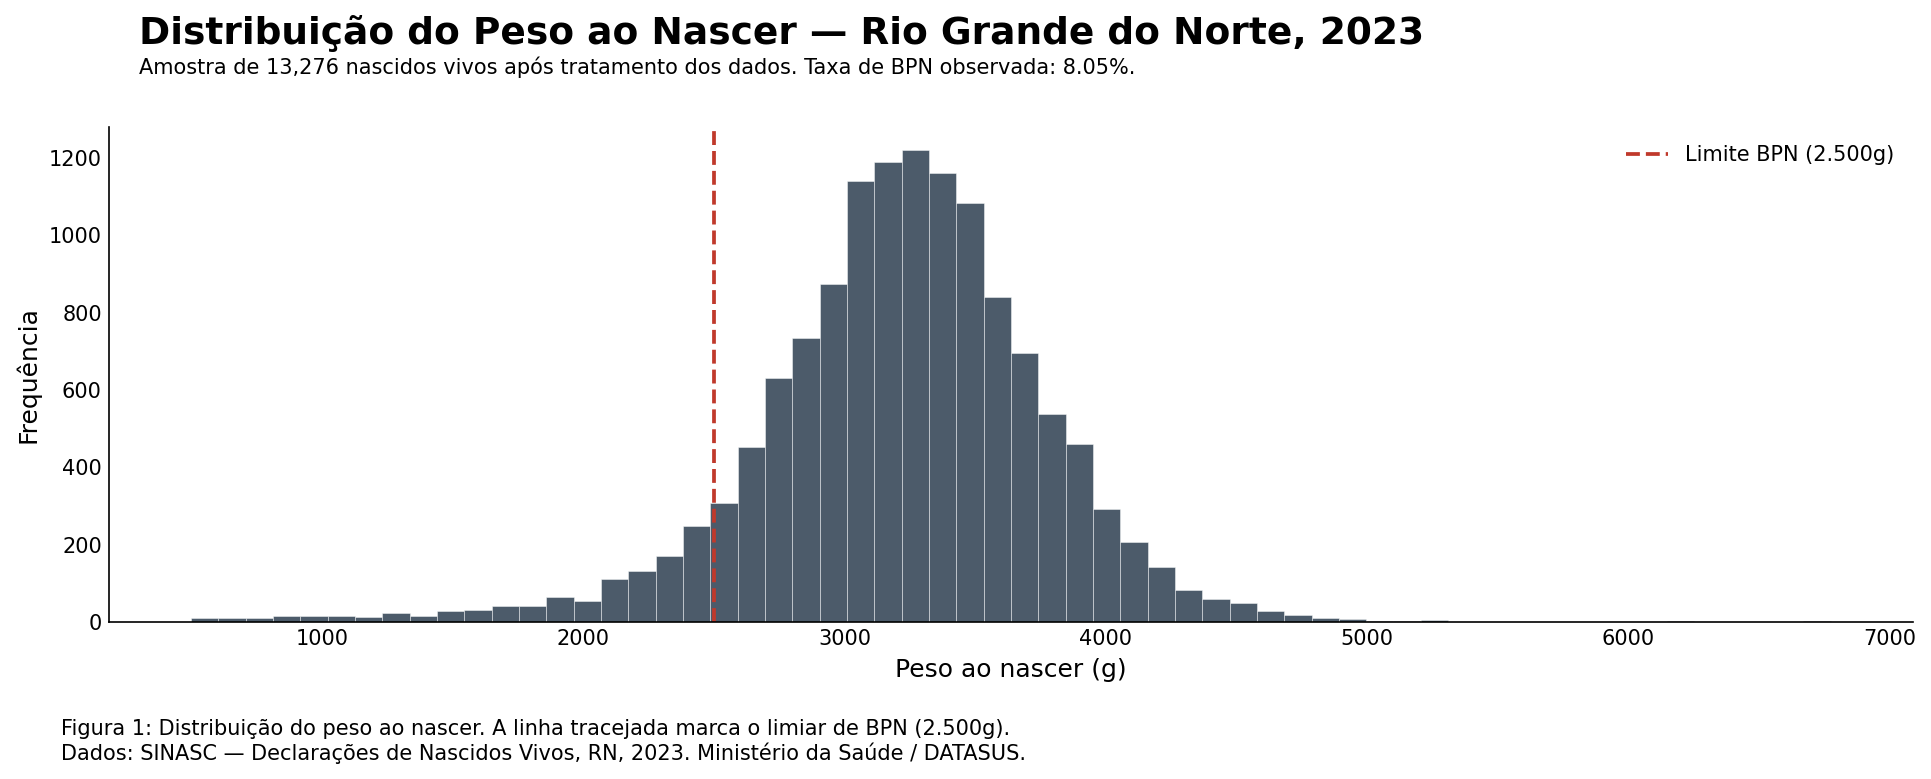

In [6]:
# fig 1: distribuição do peso ao nascer
fig, ax = plt.subplots(figsize=(13, 4))
fig.subplots_adjust(top=0.80, bottom=0.14)

ax.hist(df["peso"], bins=60, color=cinza, alpha=0.85, edgecolor="white", linewidth=0.25)
ax.axvline(
    2500, color=vermelho, linewidth=1.8, linestyle="--", label="Limite BPN (2.500g)"
)
ax.set_xlabel("Peso ao nascer (g)", fontdict=fontdict)
ax.set_ylabel("Frequência", fontdict=fontdict)
ax.legend(frameon=False, fontsize=10)
ax.tick_params(length=0)

fig.text(
    x=0.075,
    y=1.1,
    s="Distribuição do Peso ao Nascer — Rio Grande do Norte, 2023",
    fontsize=18,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.075,
    y=1.05,
    s=f"Amostra de {df.shape[0]:,} nascidos vivos após tratamento dos dados. "
    f"Taxa de BPN observada: {df.baixo_peso.mean():.2%}.",
    fontsize=10,
    color="black",
    ha="left",
)


add_caption(
    fig,
    "Figura 1: Distribuição do peso ao nascer. A linha tracejada marca o limiar de BPN (2.500g).\n"
    "Dados: SINASC — Declarações de Nascidos Vivos, RN, 2023. Ministério da Saúde / DATASUS.",
)
plt.tight_layout()
plt.show()

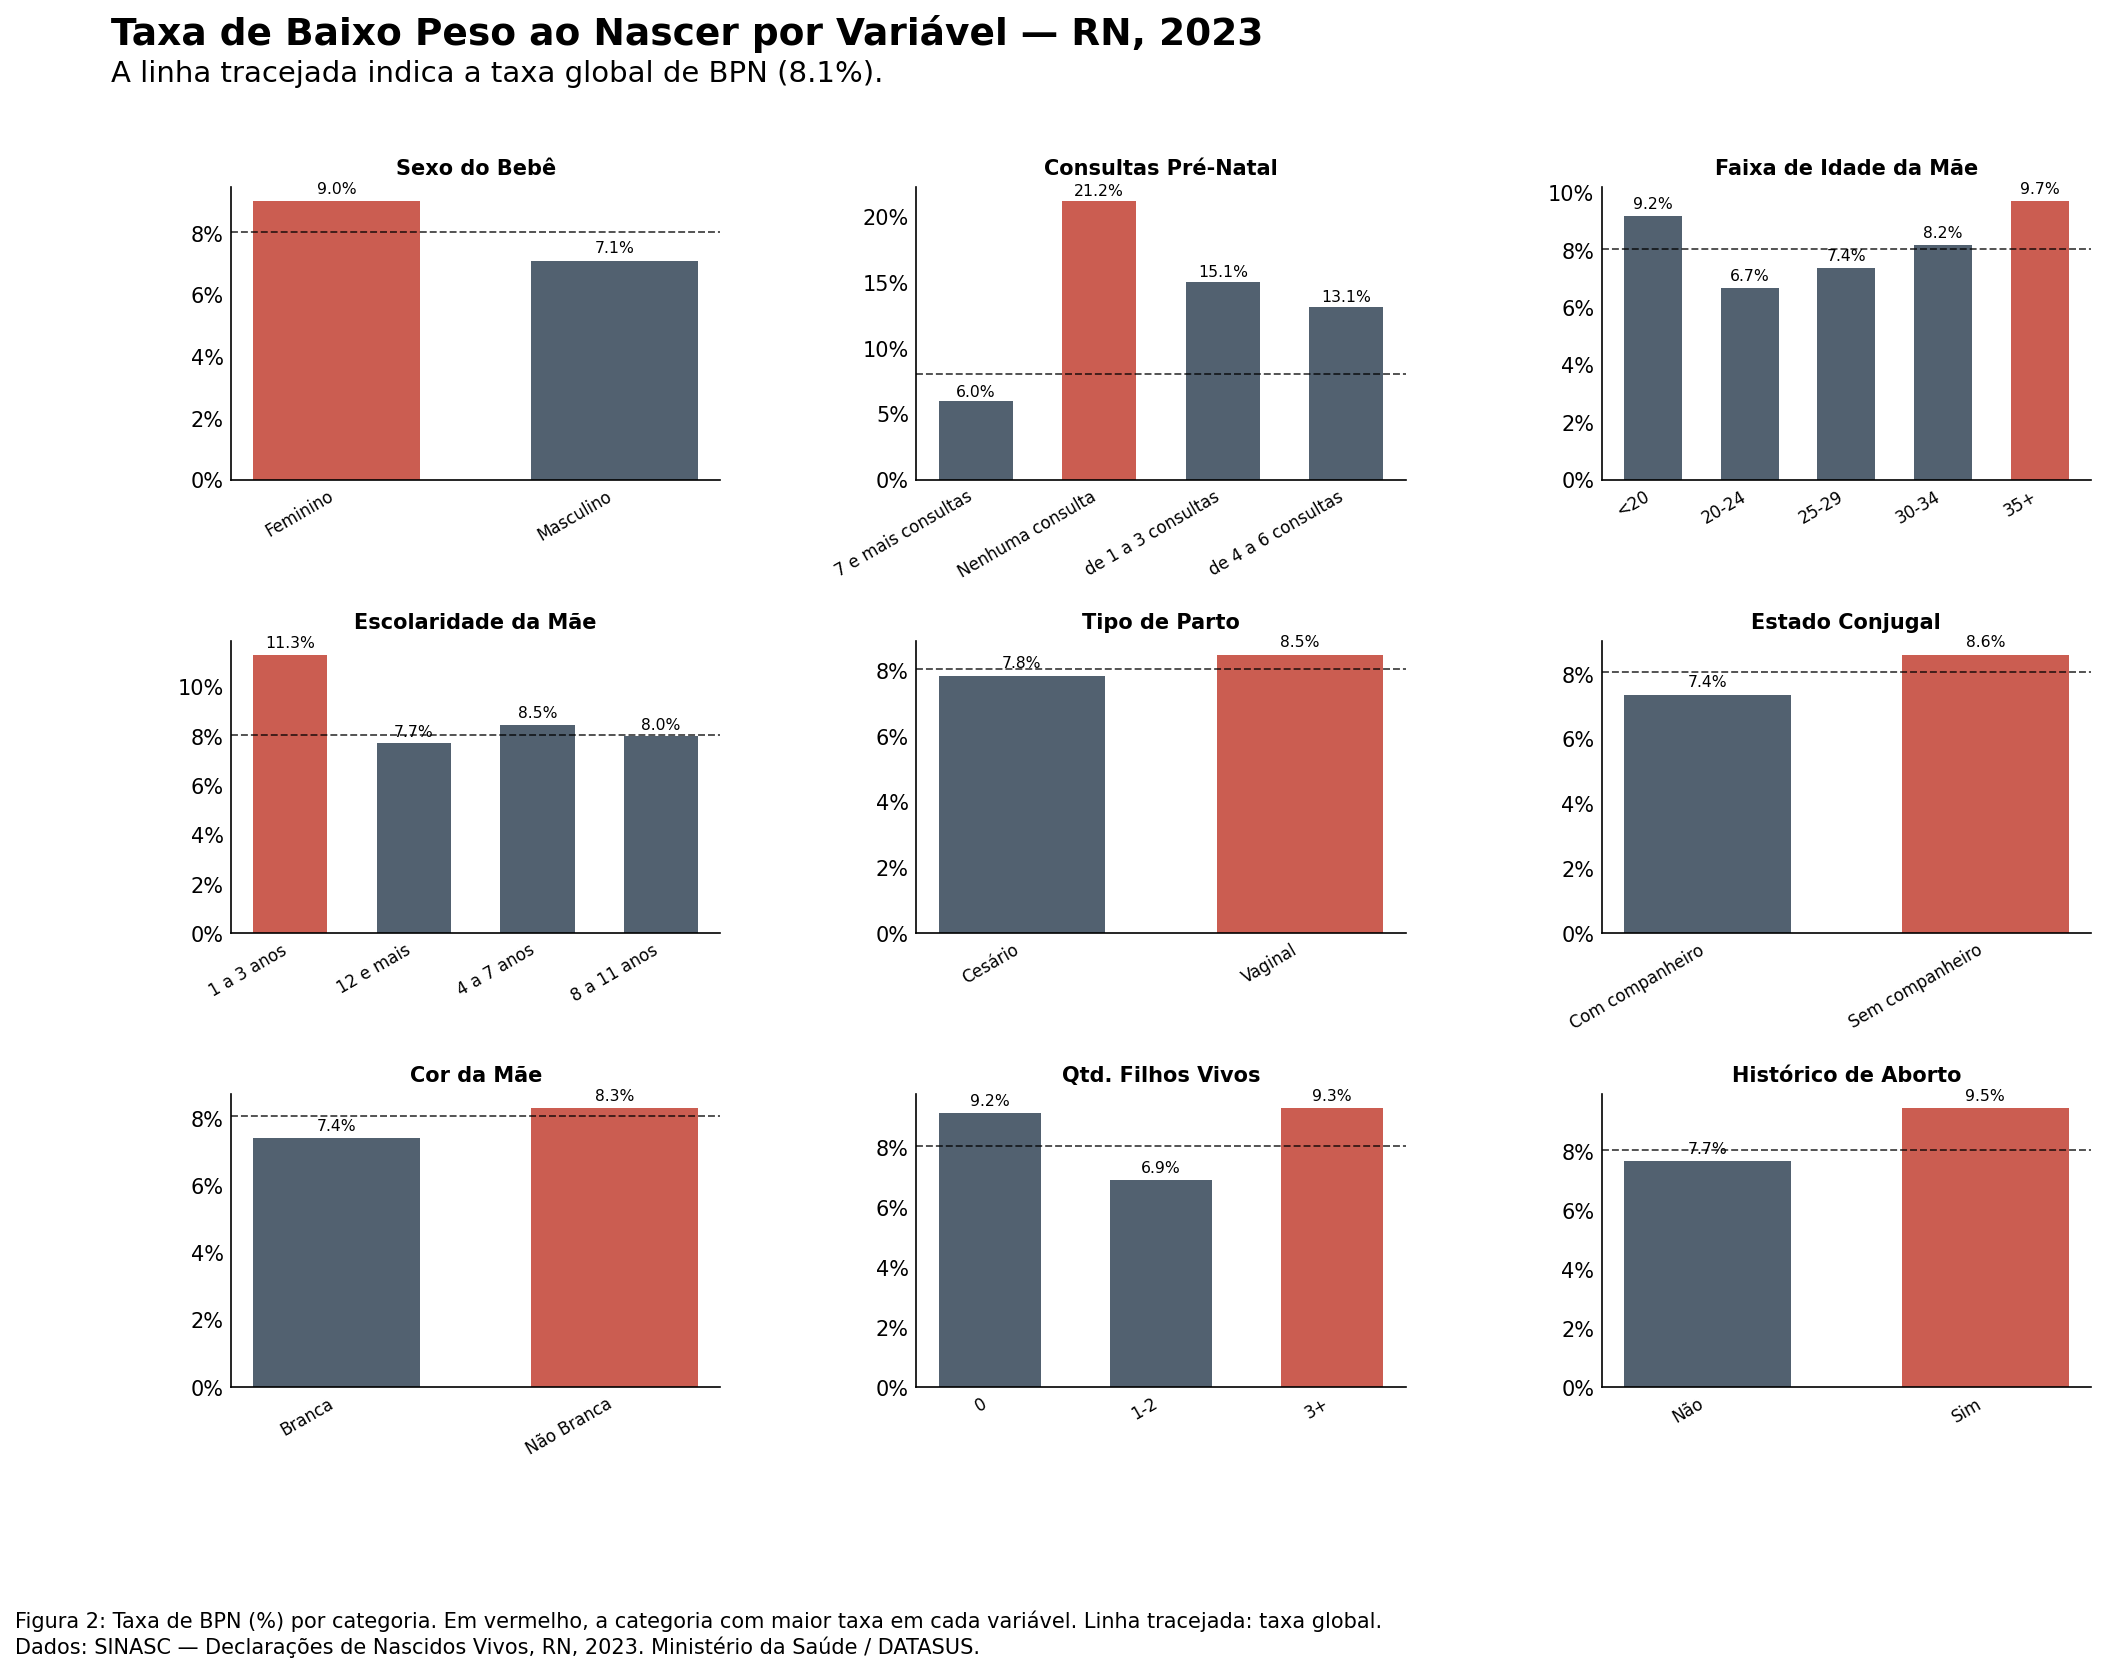

In [7]:
# fig 2: taxa de bpn por categoria
categorias = {
    "sexo": "Sexo do Bebê",
    "pre_natal_agr": "Consultas Pré-Natal",
    "faixa_idade_mae": "Faixa de Idade da Mãe",
    "escolaridade_mae": "Escolaridade da Mãe",
    "tipo_parto": "Tipo de Parto",
    "estado_conjugal_grupo": "Estado Conjugal",
    "cor_mae_branca": "Cor da Mãe",
    "faixa_filhos_vivos": "Qtd. Filhos Vivos",
    "historico_aborto": "Histórico de Aborto",
}

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.subplots_adjust(hspace=0.55, wspace=0.4, top=0.88, bottom=0.08)

fig.text(
    x=0.075,
    y=0.975,
    s="Taxa de Baixo Peso ao Nascer por Variável — RN, 2023",
    fontsize=18,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.075,
    y=0.95,
    s=f"A linha tracejada indica a taxa global de BPN ({df.baixo_peso.mean():.1%}).",
    fontsize=14,
    color="black",
    ha="left",
)

for ax, (col, title) in zip(axes.flat, categorias.items()):
    rates = taxa_bpn_por_cat(df[col], df["baixo_peso"])
    colors = [vermelho if v == rates.max() else cinza for v in rates.values]
    bars = ax.bar(range(len(rates)), rates.values, color=colors, alpha=0.82, width=0.6)
    ax.axhline(
        df.baixo_peso.mean() * 100,
        color="black",
        linewidth=0.9,
        linestyle="--",
        alpha=0.7,
    )
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, fontsize=8, rotation=30, ha="right")
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    ax.tick_params(length=0)
    for bar, val in zip(bars, rates.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f"{val:.1f}%",
            ha="center",
            va="bottom",
            fontsize=7.5,
        )

add_caption(
    fig,
    "Figura 2: Taxa de BPN (%) por categoria. Em vermelho, a categoria com maior taxa em cada variável. "
    "Linha tracejada: taxa global.\n"
    "Dados: SINASC — Declarações de Nascidos Vivos, RN, 2023. Ministério da Saúde / DATASUS.",
)

plt.show()

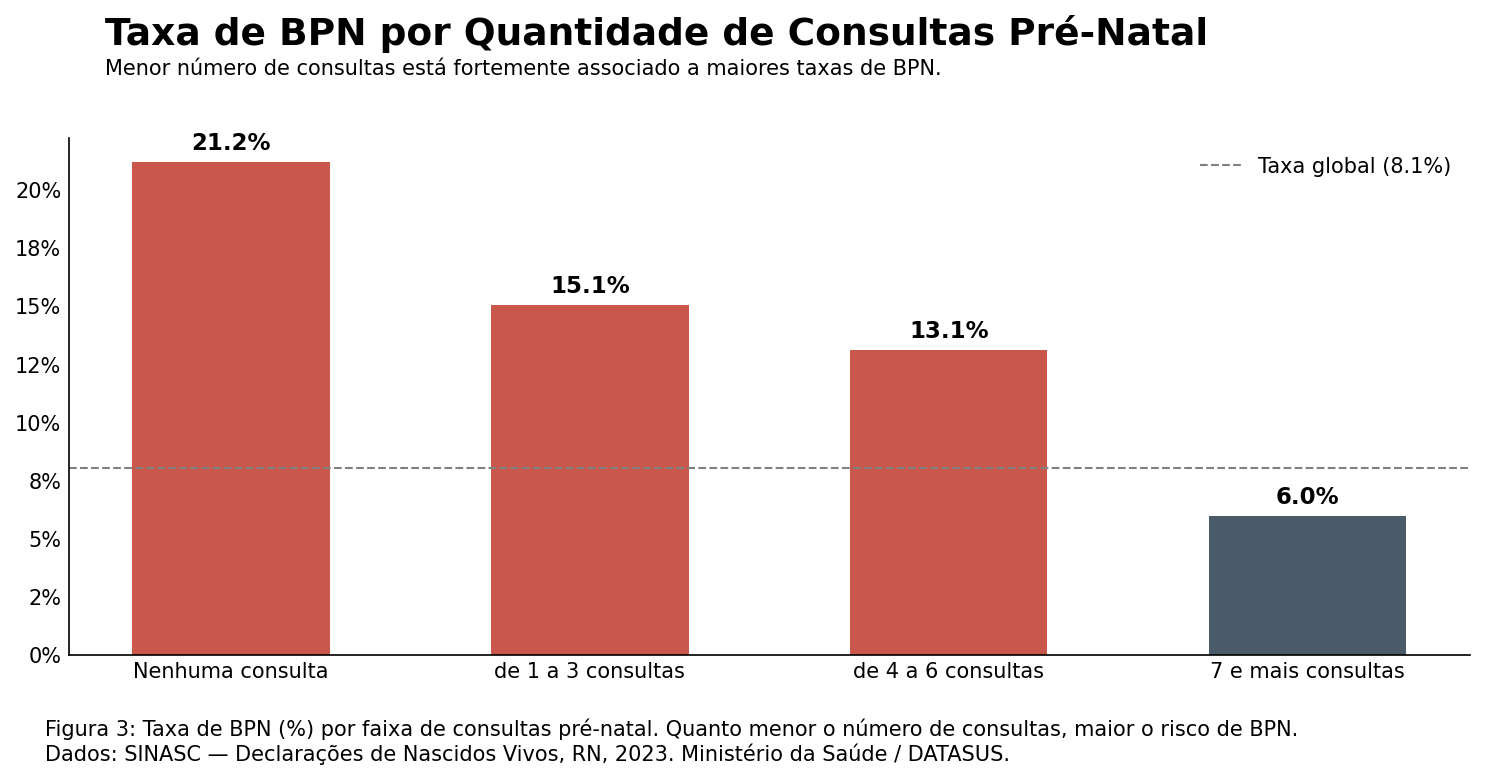

In [8]:
# fig 3: efeito das consultas pré-natal sobre o bpn
rates_prenatal = taxa_bpn_por_cat(df["pre_natal_agr"], df["baixo_peso"])

# ordenar da menor para maior consulta
ordem = [
    "Nenhuma consulta",
    "de 1 a 3 consultas",
    "de 4 a 6 consultas",
    "7 e mais consultas",
]
rates_prenatal = rates_prenatal.reindex([o for o in ordem if o in rates_prenatal.index])

fig, ax = plt.subplots(figsize=(10, 4))
fig.subplots_adjust(top=0.80, bottom=0.18)

colors = [vermelho if i < 3 else cinza for i in range(len(rates_prenatal))]
bars = ax.bar(
    range(len(rates_prenatal)),
    rates_prenatal.values,
    color=colors,
    alpha=0.85,
    width=0.55,
)

ax.axhline(
    df.baixo_peso.mean() * 100,
    color="gray",
    linewidth=1,
    linestyle="--",
    label=f"Taxa global ({df.baixo_peso.mean():.1%})",
)
ax.set_xticks(range(len(rates_prenatal)))
ax.set_xticklabels(rates_prenatal.index, fontsize=10)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))
ax.tick_params(length=0)
ax.legend(frameon=False, fontsize=10)

for bar, val in zip(bars, rates_prenatal.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

fig.text(
    x=0.075,
    y=1.1,
    s="Taxa de BPN por Quantidade de Consultas Pré-Natal",
    fontsize=18,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.075,
    y=1.05,
    s="Menor número de consultas está fortemente associado a maiores taxas de BPN.",
    fontsize=10,
    color="black",
    ha="left",
)


add_caption(
    fig,
    "Figura 3: Taxa de BPN (%) por faixa de consultas pré-natal. "
    "Quanto menor o número de consultas, maior o risco de BPN.\n"
    "Dados: SINASC — Declarações de Nascidos Vivos, RN, 2023. Ministério da Saúde / DATASUS.",
)
plt.tight_layout()
plt.show()

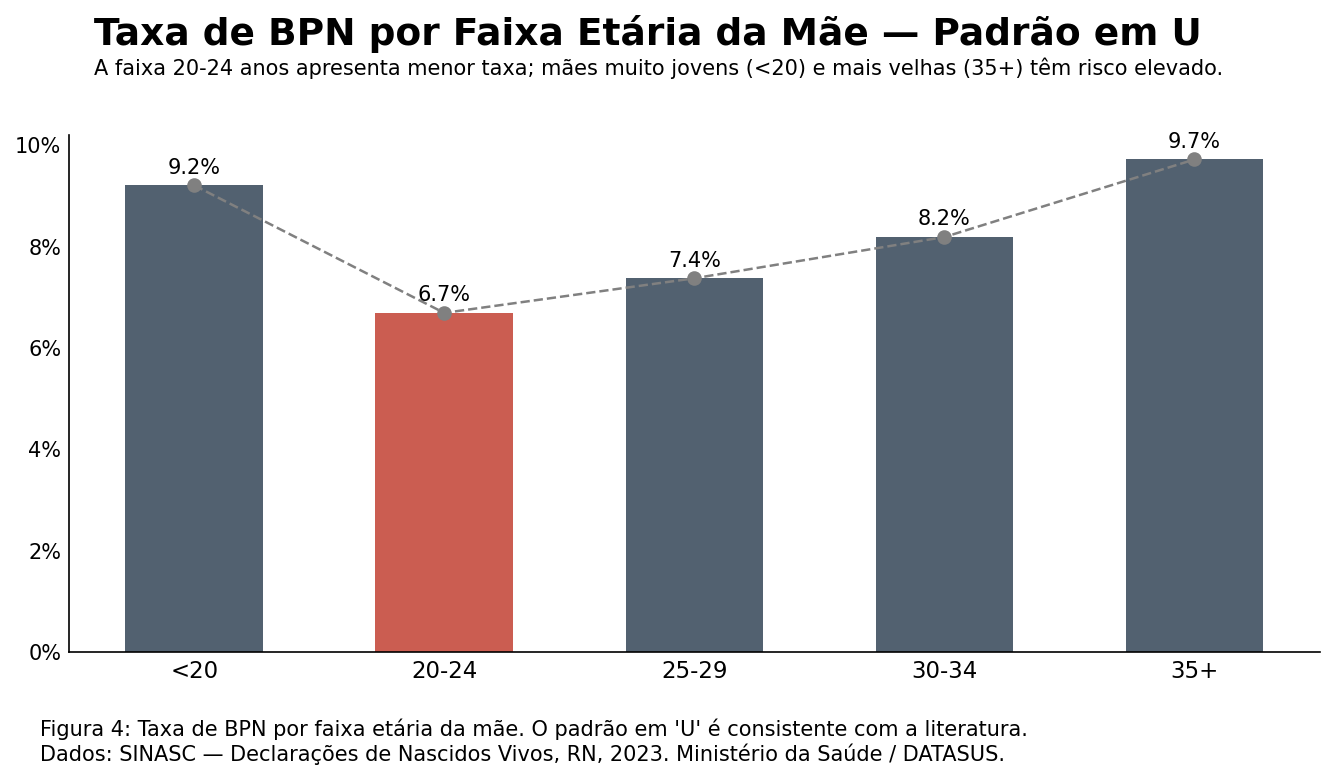

In [9]:
# fig 4: padrão em "U" da idade materna
rates_age = taxa_bpn_por_cat(df["faixa_idade_mae"], df["baixo_peso"])

fig, ax = plt.subplots(figsize=(9, 4))
fig.subplots_adjust(top=0.80, bottom=0.16)

colors = [vermelho if v == rates_age.min() else cinza for v in rates_age.values]
bars = ax.bar(
    range(len(rates_age)), rates_age.values, color=colors, alpha=0.82, width=0.55
)
ax.plot(
    range(len(rates_age)),
    rates_age.values,
    "o--",
    color="gray",
    linewidth=1.2,
    markersize=6,
)

ax.set_xticks(range(len(rates_age)))
ax.set_xticklabels(rates_age.index, fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))
ax.tick_params(length=0)
ax.legend(frameon=False, fontsize=10)

for bar, val in zip(bars, rates_age.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

fig.text(
    x=0.075,
    y=1.1,
    s="Taxa de BPN por Faixa Etária da Mãe — Padrão em U",
    fontsize=18,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.075,
    y=1.05,
    s="A faixa 20-24 anos apresenta menor taxa; mães muito jovens (<20) e mais velhas (35+) têm risco elevado.",
    fontsize=10,
    color="black",
    ha="left",
)


add_caption(
    fig,
    "Figura 4: Taxa de BPN por faixa etária da mãe. O padrão em 'U' é consistente com a literatura.\n"
    "Dados: SINASC — Declarações de Nascidos Vivos, RN, 2023. Ministério da Saúde / DATASUS.",
)
plt.tight_layout()
plt.show()

## **Modelagem**

Dois modelos são comparados:
1. **Regressão Logística**: modelo econométrico clássico, com seleção de variáveis via *backward stepwise* baseada no teste de razão de verossimilhança, que oferece interpretação direta via *odds ratios* (OR). Método sugerido pela literatura analisada.
2. **CatBoost**: modelo de *gradient boosting* com suporte nativo a variáveis categóricas e balanceamento automático de classes, o qual oferece alto poder preditivo embora perca em interpretabilidade. No estudo, a falta de interpretabilidade será compensada pelo uso de valores SHAP.

A divisão treino/teste é da proporção 80/20, estratificada pelo desfecho, garantindo que ambos os modelos sejam avaliados nas mesmas observações.

In [10]:
# variáveis categóricas e numéricas para modelagem
categoricas = [
    "sexo",
    "tipo_parto",
    "pre_natal_agr",
    "faixa_idade_mae",
    "escolaridade_mae",
    "estado_conjugal_grupo",
    "cor_mae_branca",
    "faixa_filhos_vivos",
    "historico_aborto",
]
numerica = ["semana_gestacao"]
target = "baixo_peso"

df_model = df[[target] + numerica + categoricas].copy()

# divisao treino teste estratificada (80/20)
train_idx, test_idx = train_test_split(
    df_model.index, test_size=0.2, random_state=seed, stratify=df_model[target]
)

y_train = df_model.loc[train_idx, target].astype(float)
y_test = df_model.loc[test_idx, target].astype(float)

# encoding para regressão logística
# categorias de referência são as de menor taxa de bpn, conforme indicado pela literatura
refs = {
    col: taxa_bpn_por_cat(df_model[col], df_model[target]).idxmin() for col in categoricas
}

dummies = pd.get_dummies(df_model[categoricas], drop_first=False, dtype=float)
cols_ref = [
    f"{col}_{ref}" for col, ref in refs.items() if f"{col}_{ref}" in dummies.columns
]
dummies = dummies.drop(columns=cols_ref)

X_lr = pd.concat([df_model[numerica], dummies], axis=1)
X_train_lr = X_lr.loc[train_idx]
X_test_lr = X_lr.loc[test_idx]

# dataframe para modelo CatBoost com features categóricas nativas
X_cat = df_model[numerica + categoricas].copy()
X_cat[categoricas] = X_cat[categoricas].astype(str)
X_train_cat = X_cat.loc[train_idx]
X_test_cat = X_cat.loc[test_idx]

### **Regressão Logística**

O modelo de regressão logística estima a probabilidade de BPN em função das covariáveis. A seleção de variáveis via *backward stepwise* com teste LR (nível de significância $\alpha = 0{,}05$) garante parcimônia, mantendo apenas variáveis que contribuem significativamente para o ajuste.

Os coeficientes são apresentados em termos de **_odds ratios_ (OR)**, ou razão de chances, com intervalo de confiança de 95%. Para ilustrar, um OR = 1.5 indica que a chance de BPN é 50% maior na categoria analisada em relação à categoria de referência.

In [13]:
def backward_stepwise_lr(X, y, alpha=0.05):
    """
    Seleção backward stepwise via teste de razão de verossimilhança (LR).
    Remove iterativamente a variável com p-valor LR mais alto enquanto > alpha.
    """
    features = list(X.columns)

    while features:
        X_full = sm.add_constant(X[features], has_constant="add")
        model_full = sm.GLM(y, X_full, family=sm.families.Binomial()).fit(disp=False)

        p_values = {}
        for feat in features:
            remaining = [f for f in features if f != feat]
            X_red = (
                sm.add_constant(X[remaining], has_constant="add")
                if remaining
                else pd.DataFrame({"const": np.ones(len(y))}, index=X.index)
            )
            model_red = sm.GLM(y, X_red, family=sm.families.Binomial()).fit(disp=False)
            lr_stat = 2 * (model_full.llf - model_red.llf)
            p_values[feat] = 1 - chi2.cdf(lr_stat, df=1)

        worst = max(p_values, key=p_values.get)
        if p_values[worst] > alpha:
            features.remove(worst)
        else:
            break

    X_final = sm.add_constant(X[features], has_constant="add")
    return sm.GLM(y, X_final, family=sm.families.Binomial()).fit(disp=False), features


# executando seleção backward stepwise no conjunto de treino
model_lr, selected_features = backward_stepwise_lr(X_train_lr, y_train)
selected_features

['semana_gestacao',
 'sexo_Feminino',
 'pre_natal_agr_Nenhuma consulta',
 'pre_natal_agr_de 1 a 3 consultas',
 'pre_natal_agr_de 4 a 6 consultas',
 'faixa_idade_mae_30-34',
 'faixa_idade_mae_35+',
 'faixa_filhos_vivos_0']

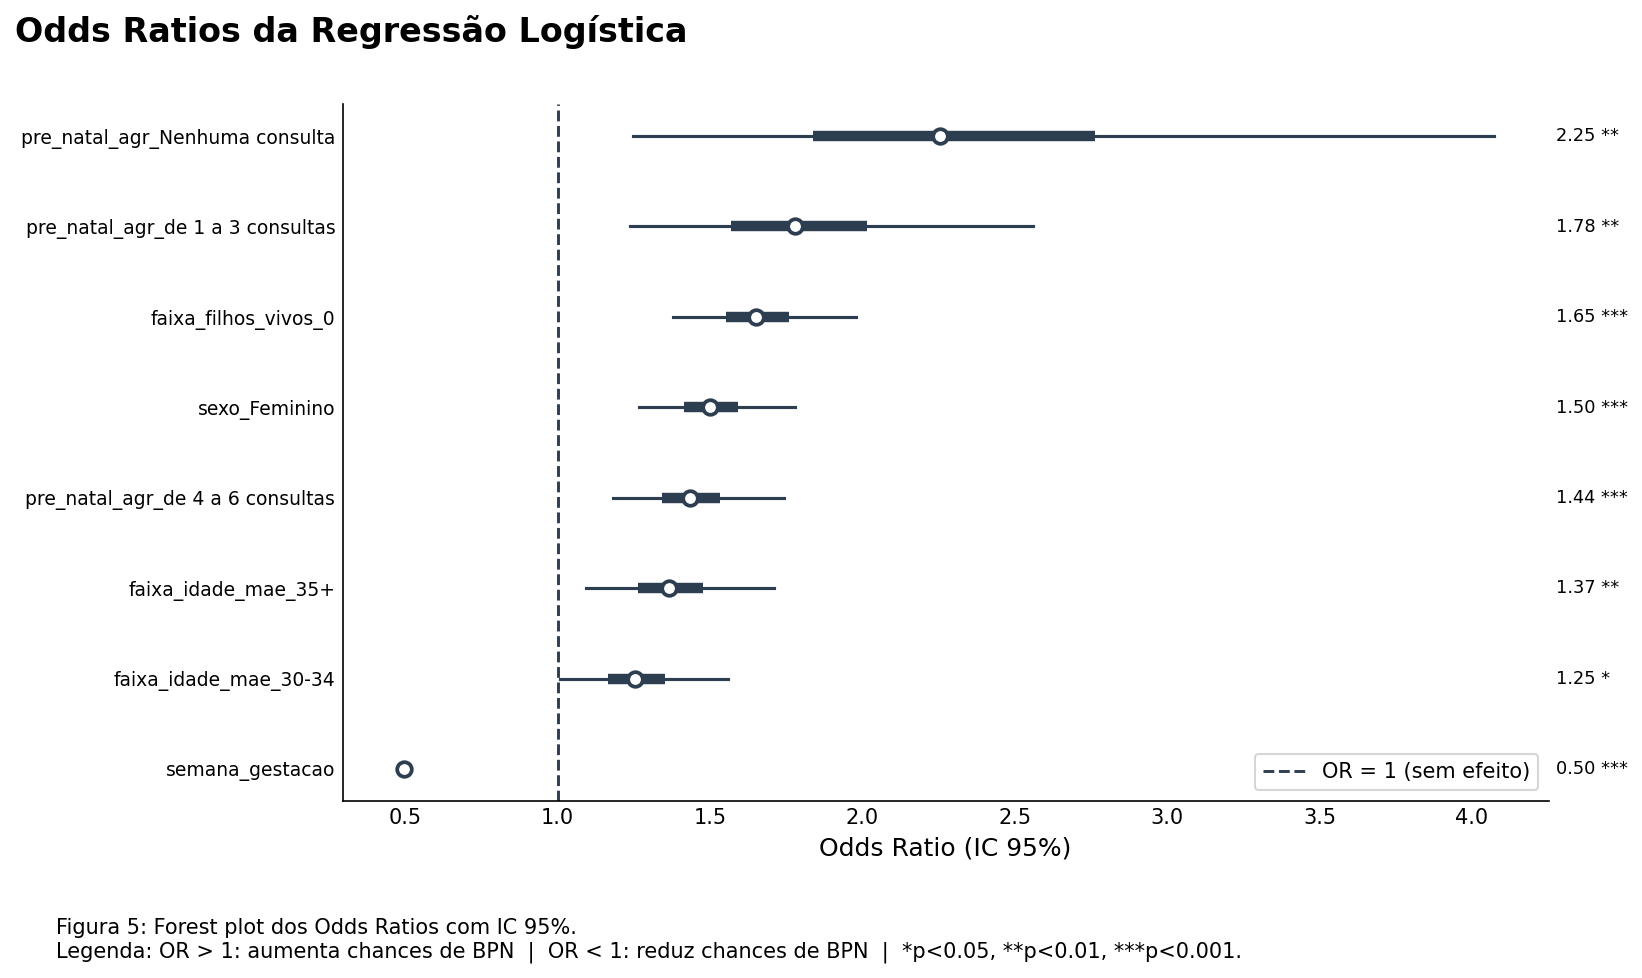

In [14]:
def plot_odds_ratio(model):
    params = model.params.drop("const")
    conf = model.conf_int().drop("const")
    p_vals = model.pvalues.drop("const")

    or_df = pd.DataFrame(
        {
            "OR": np.exp(params),
            "lower": np.exp(conf[0]),
            "upper": np.exp(conf[1]),
            "p_value": p_vals,
        }
    ).sort_values("OR")

    fig, ax = plt.subplots(figsize=(11, max(5, len(or_df) * 0.48 + 1.5)))

    fig.subplots_adjust(left=0.38, right=0.92, top=0.88, bottom=0.1)
    fig.text(
        x=0.01,
        y=1.05,
        s="Odds Ratios da Regressão Logística",
        fontsize=16,
        fontweight="bold",
        ha="left",
    )

    y_pos = list(range(len(or_df)))

    for i, (_, row) in enumerate(or_df.iterrows()):
        ax.plot(
            [row["lower"], row["upper"]], [i, i], color=cinza, linewidth=1.5, zorder=2
        )
        se = (np.log(row["upper"]) - np.log(row["lower"])) / (2 * 1.96)
        inner_lo = np.exp(np.log(row["OR"]) - 0.674 * se)
        inner_hi = np.exp(np.log(row["OR"]) + 0.674 * se)
        ax.plot(
            [inner_lo, inner_hi],
            [i, i],
            color=cinza,
            linewidth=5,
            zorder=3,
            solid_capstyle="butt",
        )
        ax.plot(
            row["OR"],
            i,
            "o",
            color=cinza,
            markerfacecolor="white",
            markeredgewidth=1.8,
            markersize=7,
            zorder=5,
        )

    # linhas de referência
    ax.axvline(
        1,
        color=cinza,
        linewidth=1.4,
        linestyle="--",
        zorder=1,
        label="OR = 1 (sem efeito)",
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(or_df.index, fontsize=9)
    ax.set_xlabel("Odds Ratio (IC 95%)", fontdict=fontdict)
    ax.tick_params(length=0)
    ax.legend()
    x_max = or_df["upper"].max()

    for i, (_, row) in enumerate(or_df.iterrows()):
        sig = (
            "***"
            if row["p_value"] < 0.001
            else "**" if row["p_value"] < 0.01 else "*" if row["p_value"] < 0.05 else ""
        )
        ax.text(x_max * 1.05, i, f"{row['OR']:.2f} {sig}", va="center", fontsize=8.5)

    add_caption(
        fig,
        "Figura 5: Forest plot dos Odds Ratios com IC 95%.\n"
        "Legenda: OR > 1: aumenta chances de BPN  |  OR < 1: reduz chances de BPN  |  *p<0.05, **p<0.01, ***p<0.001.",
    )
    plt.tight_layout()
    plt.show()


plot_odds_ratio(model_lr)

In [15]:
def evaluate_model(model_name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return pd.DataFrame(
        {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred),
            "recall_score": recall_score(y_true, y_pred),
            "f1_score": f1_score(y_true, y_pred),
        },
        index=[model_name],
    )


# previsão do teste
X_test_lr_const = sm.add_constant(X_test_lr[selected_features], has_constant="add")
y_prob_lr = model_lr.predict(X_test_lr_const)

metrics_lr = evaluate_model("Regressão Logística", y_test, y_prob_lr)
metrics_lr

,accuracy,precision,recall_score,f1_score
Regressão Logística,0.934864,0.707071,0.327103,0.447284


### **CatBoost**

O **CatBoost** é um algoritmo de *gradient boosting* que lida nativamente com variáveis categóricas sem necessidade de *one-hot encoding*, sendo mais robusto a dados tabulares mistos. O parâmetro `auto_class_weights="Balanced"` compensa automaticamente o desbalanceamento de classes (~8% de BPN vs 92% sem BPN).

A comparação com a regressão logística permite avaliar o trade-off entre poder preditivo e interpretabilidade, dado que esse é um aspecto importante na modelagens utilizadas para fundamentar políticas públicas.

In [16]:
catboost_model = CatBoostClassifier(
    random_seed=seed, auto_class_weights="Balanced", verbose=0
)
catboost_model.fit(X_train_cat, y_train, cat_features=categoricas)

# previsão sobre dados de teste
y_prob_cat = catboost_model.predict_proba(X_test_cat)[:, 1]
metrics_catboost = evaluate_model("CatBoost", y_test, y_prob_cat)
metrics_catboost

,accuracy,precision,recall_score,f1_score
CatBoost,0.83509,0.294872,0.752336,0.423684


In [21]:
total_metrics = pd.concat([metrics_lr, metrics_catboost])
total_metrics.round(3)

,accuracy,precision,recall_score,f1_score
Regressão Logística,0.935,0.707,0.327,0.447
CatBoost,0.835,0.295,0.752,0.424


### **Interpretação das Métricas**

A base tem ~8% de casos de BPN. Um modelo ingênio que simplesmente previsse todos os casos como não BPN (0) acertaria 92% das vezes, logo, a acurácia de 93,5% da regressão logística parece um ótimo resultado e poderia levar algumas pessoas a preferir o modelo em detrimento do CatBoost. Mas isto se dá devido ao desbalanceamento das classes, o que torna as métricas mais importantes a serem avaliadas o **recall**, **precisão** e o **F1-score**.

| Modelo | Acurácia | Precisão | Recall | F1 |
|:---|:---:|:---:|:---:|:---:|
| Regressão Logística | 93,5% | 70,7% | **32,7%** | 44,7% |
| CatBoost | 83,5% | 29,5% | **75,2%** | 42,4% |

- O **Recall** avalia a proporção dos casos reais de BPN que o modelo identificou corretamente. A regressão logística, sem balanceamento, deixa escapar 67% dos casos reais. O CatBoost por sua vez, que utiliza `auto_class_weights="Balanced"`, identifica 3 em cada 4 casos reais de BPN embora gere mais alertas falsos.
- A **Precisão** responde de todos os casos sinalizados como BPN, quantos o foram de fato? Na regressão logística, 7 em cada 10 alertas são verdadeiros. No CatBoost, apenas 3 em cada 10.

Dados os resultados, surge a problemática de decidir qual modelo usar, mas isso dependerá diretamente do objetivo. Por exemplo, para triagens, desenvolvimento de políticas públicas ou alertar gestantes em risco para acompanhamento intensificado o **CatBoost** é preferível, pois o recall superior indica que menos casos reais de BPN são deixados sem detecção. Isso porque o custo a longo prazo de um falso negativo é alto, muito superiores a tratamentos preventivos.
Já em casos de encaminhamento clínico com recursos limitados, ou seja, priorizar apenas casos de alta probabilidade, a **Regressão Logística** é mais criteriosa (precisão de 70,7%), o que reduziria o volume de encaminhamentos desnecessários.


## **Explicabilidade**

Para subsidiar decisões de política pública, a interpretabilidade dos modelos é essencial. Usamos duas abordagens complementares:

1. **Odds Ratios (Regressão Logística)**: já apresentados na Figura 4. Indicam diretamente *quanto a chance de BPN aumenta ou diminui* por categoria, com intervalos de confiança.

2. **SHAP (SHapley Additive exPlanations)**: método baseado na teoria dos jogos que atribui a cada variável a sua contribuição marginal para cada predição individual. Aplicado ao CatBoost, combina o poder preditivo do modelo com interpretabilidade local e global.

O **SHAP** é adequado nesse contexto pois traz a direção do efeito de cada variável (se aumenta ou reduz o risco), além de permitir análise individual (qual variável mais influenciou um caso específico) e informa quais variáveis são mais importantes no geral.

In [18]:
# calculo de SHAP values para o CatBoost no conjunto de teste
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_test_cat)

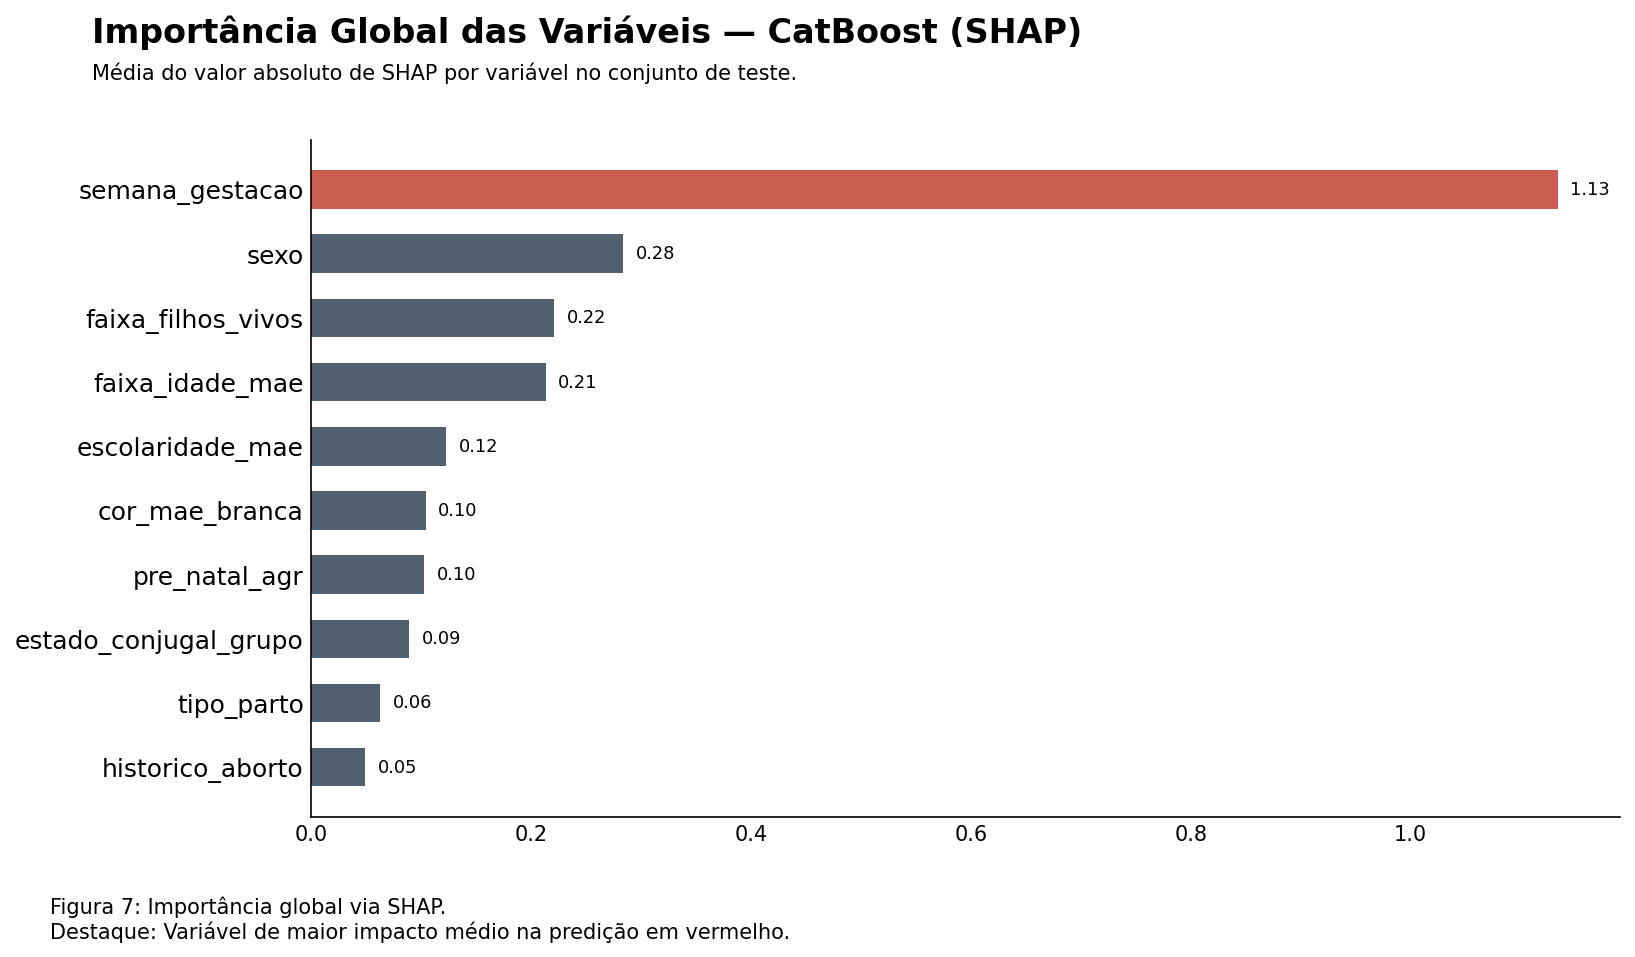

In [19]:
# fig 7: importância global das variáveis via SHAP (mean |SHAP|)
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_test_cat.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
fig.subplots_adjust(left=0.28, top=0.85, bottom=0.12, right=0.95)

colors = [vermelho if v == mean_shap.max() else cinza for v in mean_shap.values]
ax.barh(range(len(mean_shap)), mean_shap.values, color=colors, alpha=0.82, height=0.6)
ax.set_yticks(range(len(mean_shap)))
ax.set_yticklabels(mean_shap.index, fontsize=12)
ax.tick_params(length=0)

for i, val in enumerate(mean_shap.values):
    ax.text(val + mean_shap.max() * 0.01, i, f"{val:.2f}", va="center", fontsize=8.5)

fig.text(
    x=0.06,
    y=1.1,
    s="Importância Global das Variáveis — CatBoost (SHAP)",
    fontsize=16,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.06,
    y=1.05,
    s="Média do valor absoluto de SHAP por variável no conjunto de teste.",
    fontsize=10,
    color="black",
    ha="left",
)

add_caption(
    fig,
    "Figura 7: Importância global via SHAP.\n"
    "Destaque: Variável de maior impacto médio na predição em vermelho.",
)
plt.tight_layout()
plt.show()

O SHAP mede o quanto cada variável influencia, em média, as previsões do CatBoost em cada observação. O comprimento da barra é a média do valor absoluto do impacto: quanto maior, mais aquela variável pesou nas decisões do modelo.


1. **`semana_gestacao`** é a variável mais importante (SHAP médio = 1,13), enquanto o segundo colocado, `sexo`, tem apenas 0,28 — ou seja, a semana gestacional influencia quase **4× mais** do que qualquer outro fator. Isso indica e confirma que a prematuridade é o principal fator biológico do BPN: bebês prematuros nascem com menos tempo de desenvolvimento intrauterino e, consequentemente, pesam menos.
- **`sexo`** ocupa a segunda posição, refletindo que bebês do sexo feminino têm, em média, peso ao nascer ligeiramente menor. A análise é consistente com a literatura analisada.
- **`faixa_filhos_vivos`** e **`faixa_idade_mae`** aparecem empatados, indicando que o histórico reprodutivo e a idade materna são os principais fatores sociodemográficos após controlar a gestação.
- **`pre_natal_agr`** aparece abaixo do esperado, não porque a variável seja irrelevante, mas porque, depois de controlar a semana gestacional, seu poder preditivo adicional é reduzido, ou seja: gestantes sem pré-natal tendem também a ter gestações mais prematuras, logo o modelo tende a atribuir o efeito principal à semana gestacional.
- **`historico_aborto`** tem o menor impacto individual no CatBoost, apesar de relevante na análise descritiva.


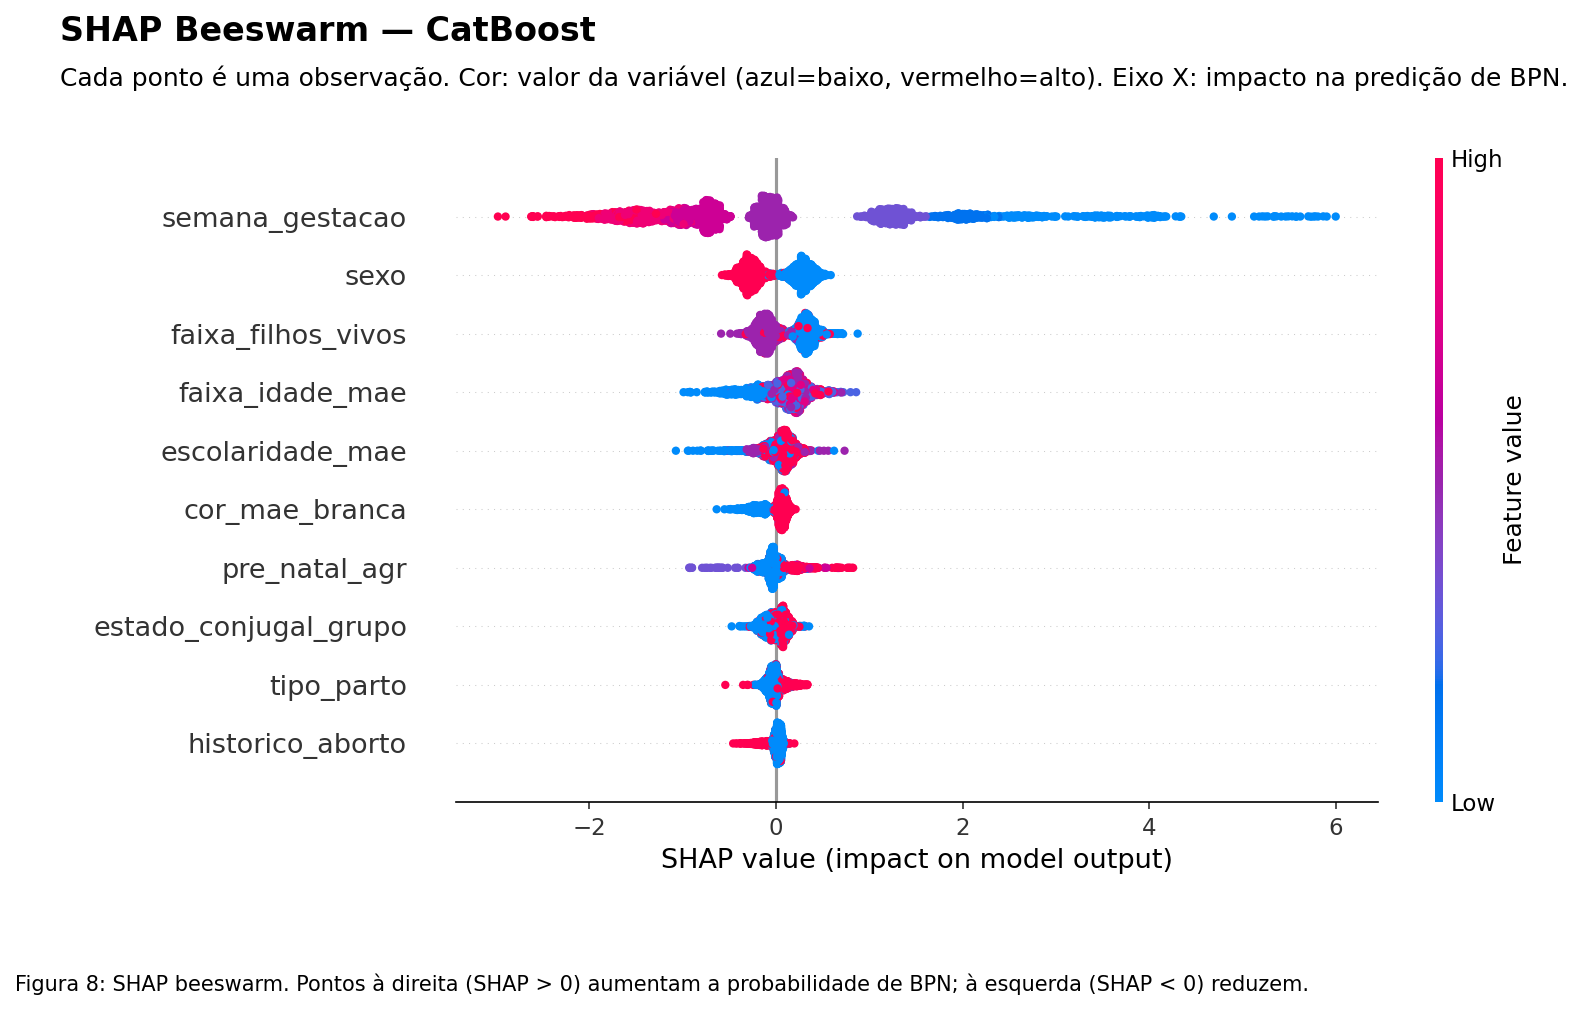

In [20]:
# fig 8: SHAP beeswarm
X_test_cat_encoded = X_test_cat.copy()
for col in categoricas:
    X_test_cat_encoded[col] = pd.Categorical(X_test_cat[col]).codes.astype(float)

shap.summary_plot(shap_values, X_test_cat_encoded, max_display=10, show=False)

fig = plt.gcf()
fig.set_size_inches(12, 6)
fig.subplots_adjust(top=0.83, left=0.28, right=0.92)

fig.text(
    x=0.06,
    y=0.96,
    s="SHAP Beeswarm — CatBoost",
    fontsize=16,
    fontweight="bold",
    ha="left",
)
fig.text(
    x=0.06,
    y=0.91,
    s="Cada ponto é uma observação. Cor: valor da variável (azul=baixo, vermelho=alto). "
    "Eixo X: impacto na predição de BPN.",
    fontsize=12,
    color="black",
    ha="left",
)

add_caption(
    fig,
    "Figura 8: SHAP beeswarm. Pontos à direita (SHAP > 0) aumentam a probabilidade de BPN; "
    "à esquerda (SHAP < 0) reduzem.",
)
plt.show()

O gráfico de importância anterior mostrou quanto cada variável importa no modelo globalmente. O beeswarm mostra para quais observações, qual a direção e com qual intensidade cada variável influenciou a predição.

Cada ponto é uma observação do conjunto de teste. O eixo X é o impacto SHAP daquela variável naquele caso específico:
- **SHAP > 0** (direita da linha zero) indica que aquela variável, naquela observação, aumentou a probabilidade de BPN.
- **SHAP < 0** (esquerda) indica que aquela variável, com o valor atribuído, reduziu a probabilidade de BPN.
- A **cor** indica o valor da feature, sendo vermelho valor alto, azul valor baixo.

### **Interpretação**

- **`semana_gestacao`**: pontos azuis (prematuros, poucos semanas) estão concentrados à **direita**, indicando que prematuridade aumenta muito o risco de BPN.
- **`sexo`**: a separação de cores mostra que um dos sexos (feminino = 1, valor mais alto comparado a masculino = 0) apresenta SHAP levemente positivo, ou seja: sexo feminino aumenta o risco comparado ao masculino.
- **`faixa_filhos_vivos`**: valores baixos (primeiras gestações) tendem a apresentar valor SHAP positivo.
- **`faixa_idade_mae`**: valores extremos aumentam a probabilidade de BPN, resultado consistente com o padrão em "U" observado na análise exploratória.

As demais variáveis (`escolaridade_mae`, `pre_natal_agr`, `estado_conjugal_grupo` etc.) apresentam distribuição mais concentrada em torno de zero, com efeitos menores e menos dispersos.

## **Conclusões**

**Os resultados da análise econométrica confirmam os achados da literatura nacional sobre os fatores associados ao baixo peso ao nascer no Rio Grande do Norte:**

1. Semanas de gestação é o fator de maior impacto individual, onde cada semana adicional reduz significativamente o risco de BPN. Tanto a regressão logística quanto o CatBoost via SHAP confirmam esse ponto.
2. Consultas pré-natal apresentam gradiente onde gestantes com nenhuma ou poucas consultas têm risco maior. Isso sinaliza a importância da atenção básica e do acesso à saúde para populações vulneráveis.
3. Sexo feminino aumenta o risco de BPN. O achado é consistente com a literatura neonatal analisada.
4. Histórico de aborto e ausência de filhos vivos anteriores também elevam o risco de BPN, indicando que o histórico reprodutivo da mãe é um fator que merece atenção especial no acompanhamento pré-natal.
5. Idade materna avançada (30-34 e 35+) aumenta o risco em comparação com mães de 20-24 anos.

**Do ponto de vista do desenvolvimento de políticas públicas, os resultados reforçam a necessidade de:**
1. Fortalecer a atenção básica e garantir acesso ao pré-natal completo (≥7 consultas), especialmente em populações vulneráveis.
2. Priorizar atenção especializada para gestantes com histórico de aborto, primeiras gestações e mães com 35+ anos.
3. Monitorar prematuridade como principal fator de risco clínico.

A análise dos dois modelos (Regressão Logística e CatBoost + SHAP) permite tanto a interpretação causal estruturada quanto a identificação de padrões complexos, sendo complementares para a tomada de decisão baseada em evidências.

## **Referências**

**Dados:**  
SINASC — Sistema de Informações sobre Nascidos Vivos. Ministério da Saúde / DATASUS. Declarações de Nascidos Vivos, Rio Grande do Norte, 2023. Disponível em: https://datasus.saude.gov.br/

**Literatura sobre BPN no Brasil:** 
1. Tolio, F. B., Moraes, A. B. e Jacobi, L. F. (2020). *Identificação de fatores de risco para o baixo peso ao nascer — uma análise de regressão logística*. Ciência e Natura, 42, e23. https://doi.org/10.5902/2179460X40497  
2. Carniel, E. F. et al. (2008). *Determinantes do baixo peso ao nascer a partir das Declarações de Nascidos Vivos*. Revista Brasileira de Epidemiologia, 11(1), 169–179.  
3. Moreira, A. I. M., Sousa, P. R. M. e Sarno, F. (2018). *Baixo peso ao nascer e seus fatores associados*. einstein (São Paulo), 16(4), eAO4251.

**Metodologia:** 
1. Hosmer, D., Lemeshow, S. e Sturdivant, R. X. (2013). *Applied Logistic Regression*. 3rd Edition, Wiley. https://doi.org/10.1002/9781118548387  
2. Prokhorenkova, L. et al. (2018). *CatBoost: unbiased boosting with categorical features*. Advances in Neural Information Processing Systems, 31.  
3. Lundberg, S. M. e Lee, S.-I. (2017). *A unified approach to interpreting model predictions*. Advances in Neural Information Processing Systems, 30.
4. Molnar, C. (2022). *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable*. 2nd Edition. https://christophm.github.io/interpretable-ml-book/
